HDF5 file structure:
centers: <class 'h5py._hl.dataset.Dataset'>
  Shape: (2248, 3)
  Type: float64
dx: <class 'h5py._hl.dataset.Dataset'>
  Shape: (14,)
  Type: float64
dy: <class 'h5py._hl.dataset.Dataset'>
  Shape: (14,)
  Type: float64
dz: <class 'h5py._hl.dataset.Dataset'>
  Shape: (14,)
  Type: float64
levels: <class 'h5py._hl.dataset.Dataset'>
  Shape: (2248,)
  Type: int64
var_data: <class 'h5py._hl.dataset.Dataset'>
  Shape: (30, 2248, 7, 7, 7)
  Type: float64
vars: <class 'h5py._hl.dataset.Dataset'>
  Shape: (30,)
  Type: object
vars_use: <class 'h5py._hl.dataset.Dataset'>
  Shape: (0,)
  Type: float64

Data shapes:
Variable data shape: (30, 2248, 7, 7, 7)
Centers shape: (2248, 3)
Levels shape: (2248,)

Number of variables: 30
Variable names:
0: U_ALPHA
1: U_CHI
2: U_K
3: U_GT0
4: U_GT1
5: U_GT2
6: U_BETA0
7: U_BETA1
8: U_BETA2
9: U_B0
10: U_B1
11: U_B2
12: U_SYMGT0
13: U_SYMGT1
14: U_SYMGT2
15: U_SYMGT3
16: U_SYMGT4
17: U_SYMGT5
18: U_SYMAT0
19: U_SYMAT1
20: U_SYMAT2
21: U_S

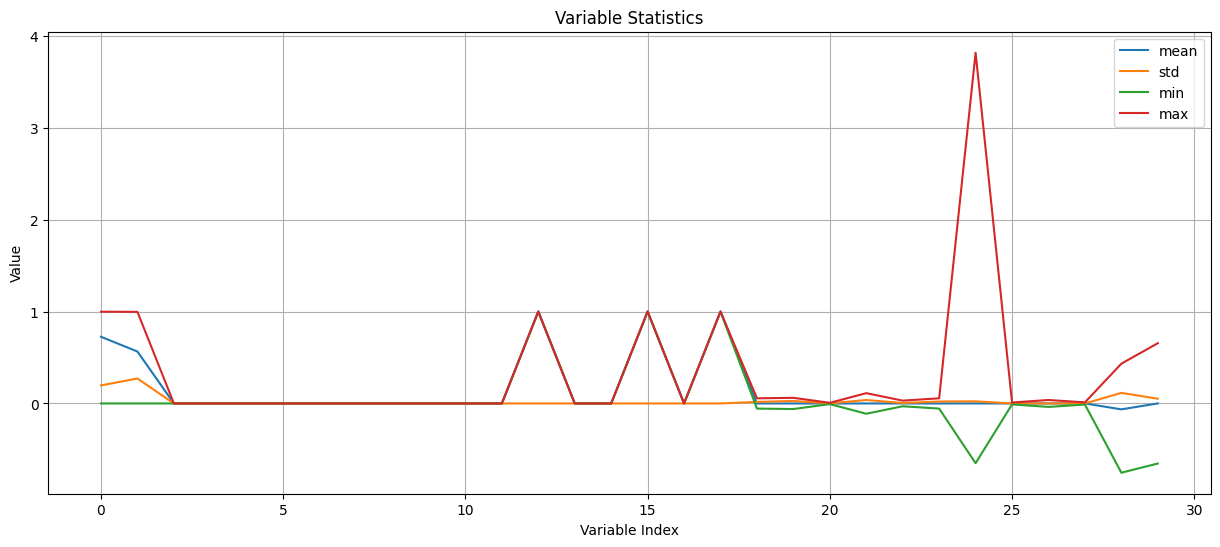

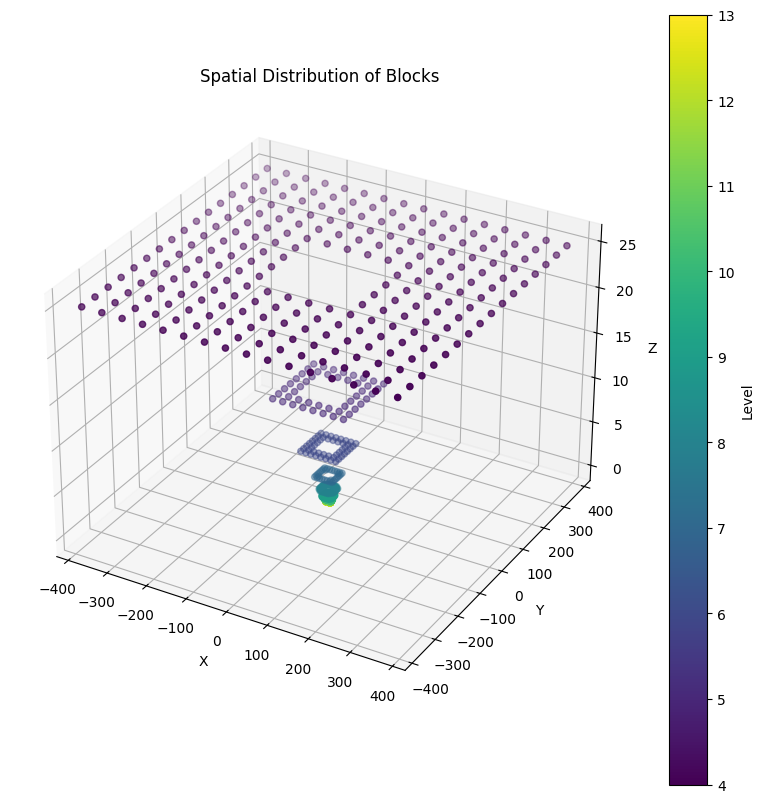

/opt/miniconda3/envs/401kpro/lib/python3.9/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/401kpro/lib/python3.9/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


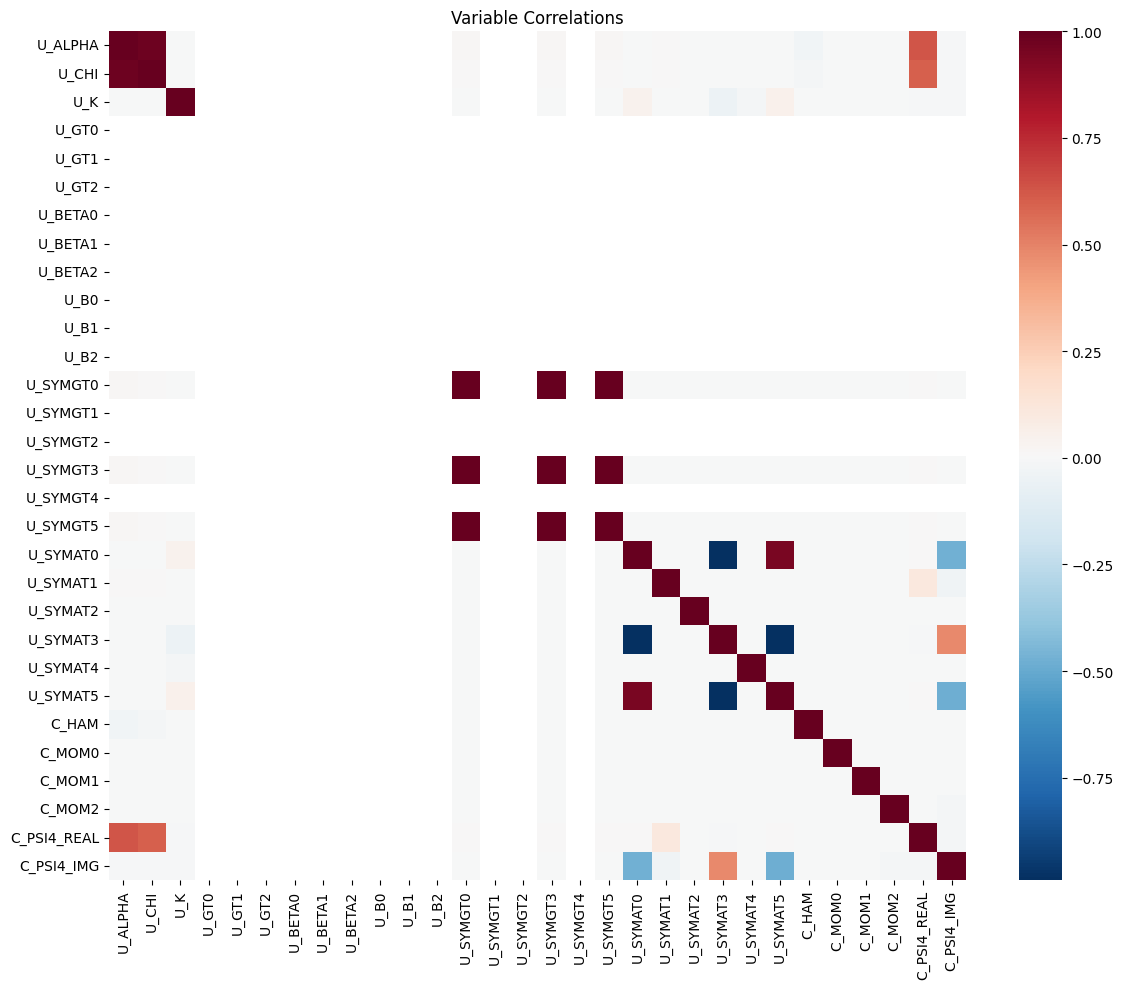

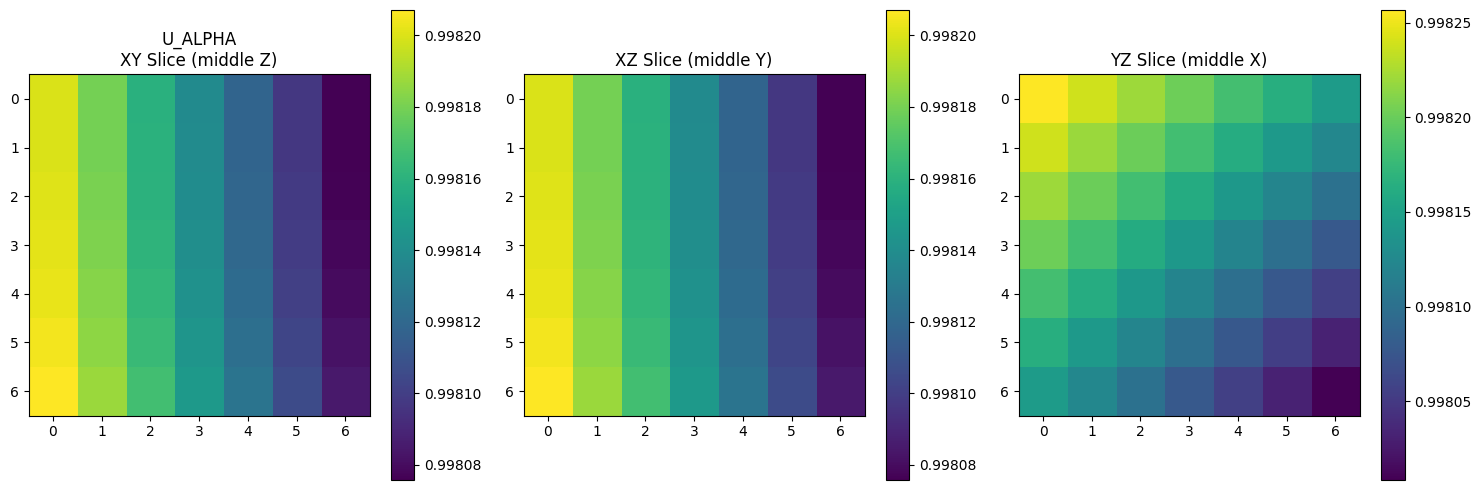

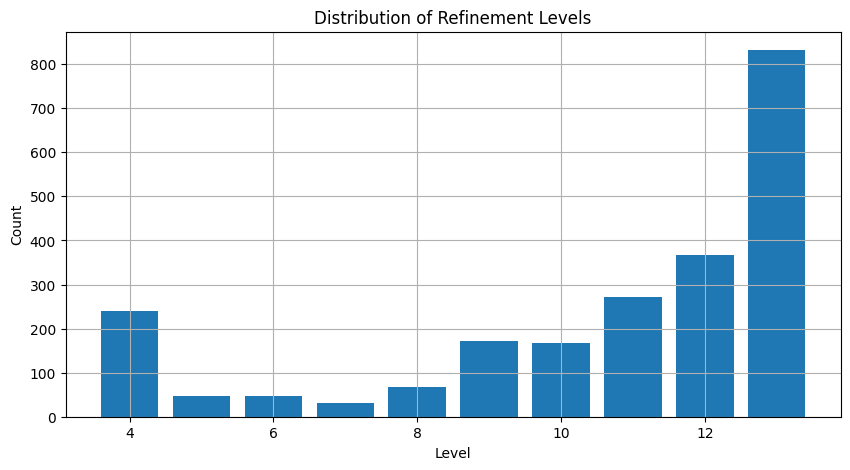


Core data statistics:
Shape of core data: (30, 2248, 5, 5, 5)
Original shape: (30, 2248, 7, 7, 7)

Comparison of original vs core:
Original block size: (7, 7, 7) (7x7x7)
Core block size: (5, 5, 5) (5x5x5)


In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# First, let's examine the structure of your HDF5 file
def print_hdf5_structure(filename):
    with h5py.File(filename, "r") as f:
        print("HDF5 file structure:")
        def print_structure(name, obj):
            print(f"{'  ' * name.count('/')}{name}: {type(obj)}")
            if isinstance(obj, h5py.Dataset):
                print(f"{'  ' * (name.count('/')+1)}Shape: {obj.shape}")
                print(f"{'  ' * (name.count('/')+1)}Type: {obj.dtype}")
        f.visititems(print_structure)

# Print the structure
filename = "bssn_gr_0_extracted.hdf5"
print_hdf5_structure(filename)

# Now let's read the actual data structure
def read_data(filename):
    with h5py.File(filename, "r") as f:
        var_names = f["vars"][:]
        var_data = f["var_data"][:]
        centers = f["centers"][:]
        levels = f["levels"][:]
        dx = f["dx"][:]
        dy = f["dy"][:]
        dz = f["dz"][:]
        
    return var_names, var_data, centers, levels, dx, dy, dz

# Load the data
var_names, var_data, centers, levels, dx, dy, dz = read_data(filename)

# Print basic information
print("\nData shapes:")
print(f"Variable data shape: {var_data.shape}")
print(f"Centers shape: {centers.shape}")
print(f"Levels shape: {levels.shape}")
print(f"\nNumber of variables: {len(var_names)}")
print("Variable names:")
for i, name in enumerate(var_names):
    if isinstance(name, bytes):
        name = name.decode('utf-8')
    print(f"{i}: {name}")

# Extract 5x5x5 cores from 7x7x7 blocks
def extract_core(var_data):
    """Extract 5x5x5 core from 7x7x7 blocks"""
    if len(var_data.shape) == 5:  # For the full dataset
        return var_data[:, :, 1:-1, 1:-1, 1:-1]
    elif len(var_data.shape) == 3:  # For a single block
        return var_data[1:-1, 1:-1, 1:-1]
    else:
        raise ValueError(f"Unexpected shape: {var_data.shape}")

# Basic statistics for each variable
var_stats = {
    'mean': np.mean(var_data.reshape(var_data.shape[0], -1), axis=1),
    'std': np.std(var_data.reshape(var_data.shape[0], -1), axis=1),
    'min': np.min(var_data.reshape(var_data.shape[0], -1), axis=1),
    'max': np.max(var_data.reshape(var_data.shape[0], -1), axis=1)
}

# Plot statistics for each variable
plt.figure(figsize=(15, 6))
for stat_name, stat_values in var_stats.items():
    plt.plot(stat_values, label=stat_name)
plt.title('Variable Statistics')
plt.xlabel('Variable Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

# Plot spatial distribution of blocks
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(centers[:, 0], 
                    centers[:, 1], 
                    centers[:, 2],
                    c=levels,
                    cmap='viridis')
plt.colorbar(scatter, label='Level')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.title('Spatial Distribution of Blocks')
plt.show()

# Plot correlation matrix between variables
corr_matrix = np.corrcoef([var_data[i].flatten() for i in range(len(var_names))])
plt.figure(figsize=(12, 10))
var_labels = [name.decode('utf-8') if isinstance(name, bytes) else name for name in var_names]
sns.heatmap(corr_matrix, 
            xticklabels=var_labels,
            yticklabels=var_labels,
            cmap='RdBu_r')
plt.title('Variable Correlations')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Visualize middle slices of the first variable for a single block
plt.figure(figsize=(15, 5))
first_block_idx = 0  # First block
first_var_idx = 0    # First variable

# Plot XY, XZ, and YZ middle slices
plt.subplot(131)
plt.imshow(var_data[first_var_idx, first_block_idx, :, :, 3], cmap='viridis')
plt.title(f'{var_labels[first_var_idx]}\nXY Slice (middle Z)')
plt.colorbar()

plt.subplot(132)
plt.imshow(var_data[first_var_idx, first_block_idx, :, 3, :], cmap='viridis')
plt.title('XZ Slice (middle Y)')
plt.colorbar()

plt.subplot(133)
plt.imshow(var_data[first_var_idx, first_block_idx, 3, :, :], cmap='viridis')
plt.title('YZ Slice (middle X)')
plt.colorbar()

plt.tight_layout()
plt.show()

# Distribution of refinement levels
plt.figure(figsize=(10, 5))
plt.hist(levels, bins=np.arange(levels.min(), levels.max()+2)-0.5,
         rwidth=0.8)
plt.title('Distribution of Refinement Levels')
plt.xlabel('Level')
plt.ylabel('Count')
plt.grid(True)
plt.show()

# Print some statistics about the 5x5x5 cores
core_data = extract_core(var_data)
print("\nCore data statistics:")
print(f"Shape of core data: {core_data.shape}")
print(f"Original shape: {var_data.shape}")
print("\nComparison of original vs core:")
print(f"Original block size: {var_data.shape[2:]} (7x7x7)")
print(f"Core block size: {core_data.shape[2:]} (5x5x5)")

HDF5 file structure:
centers: <class 'h5py._hl.dataset.Dataset'>
  Shape: (2218, 3)
  Type: float64
dx: <class 'h5py._hl.dataset.Dataset'>
  Shape: (14,)
  Type: float64
dy: <class 'h5py._hl.dataset.Dataset'>
  Shape: (14,)
  Type: float64
dz: <class 'h5py._hl.dataset.Dataset'>
  Shape: (14,)
  Type: float64
levels: <class 'h5py._hl.dataset.Dataset'>
  Shape: (2218,)
  Type: int64
var_data: <class 'h5py._hl.dataset.Dataset'>
  Shape: (30, 2218, 7, 7, 7)
  Type: float64
vars: <class 'h5py._hl.dataset.Dataset'>
  Shape: (30,)
  Type: object
vars_use: <class 'h5py._hl.dataset.Dataset'>
  Shape: (0,)
  Type: float64

Data shapes:
Variable data shape: (30, 2218, 7, 7, 7)
Centers shape: (2218, 3)
Levels shape: (2218,)

Number of variables: 30
Variable names:
0: U_ALPHA
1: U_CHI
2: U_K
3: U_GT0
4: U_GT1
5: U_GT2
6: U_BETA0
7: U_BETA1
8: U_BETA2
9: U_B0
10: U_B1
11: U_B2
12: U_SYMGT0
13: U_SYMGT1
14: U_SYMGT2
15: U_SYMGT3
16: U_SYMGT4
17: U_SYMGT5
18: U_SYMAT0
19: U_SYMAT1
20: U_SYMAT2
21: U_S

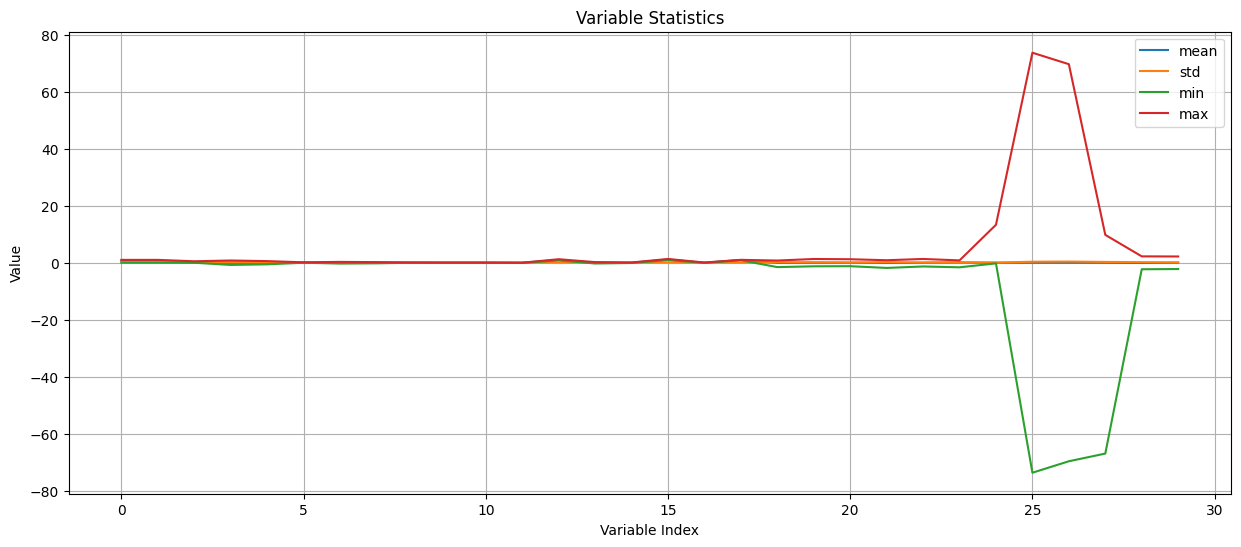

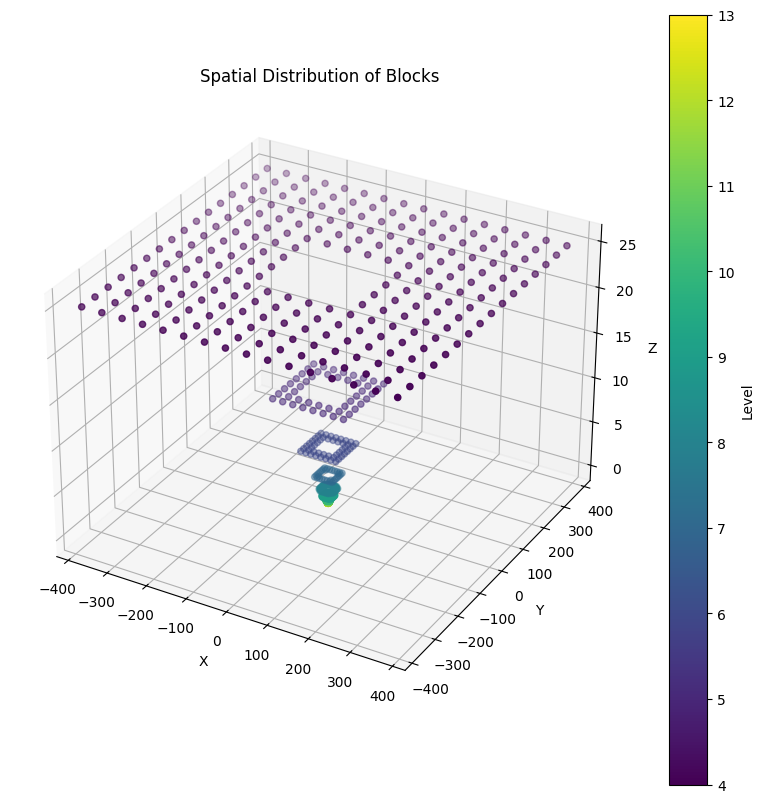

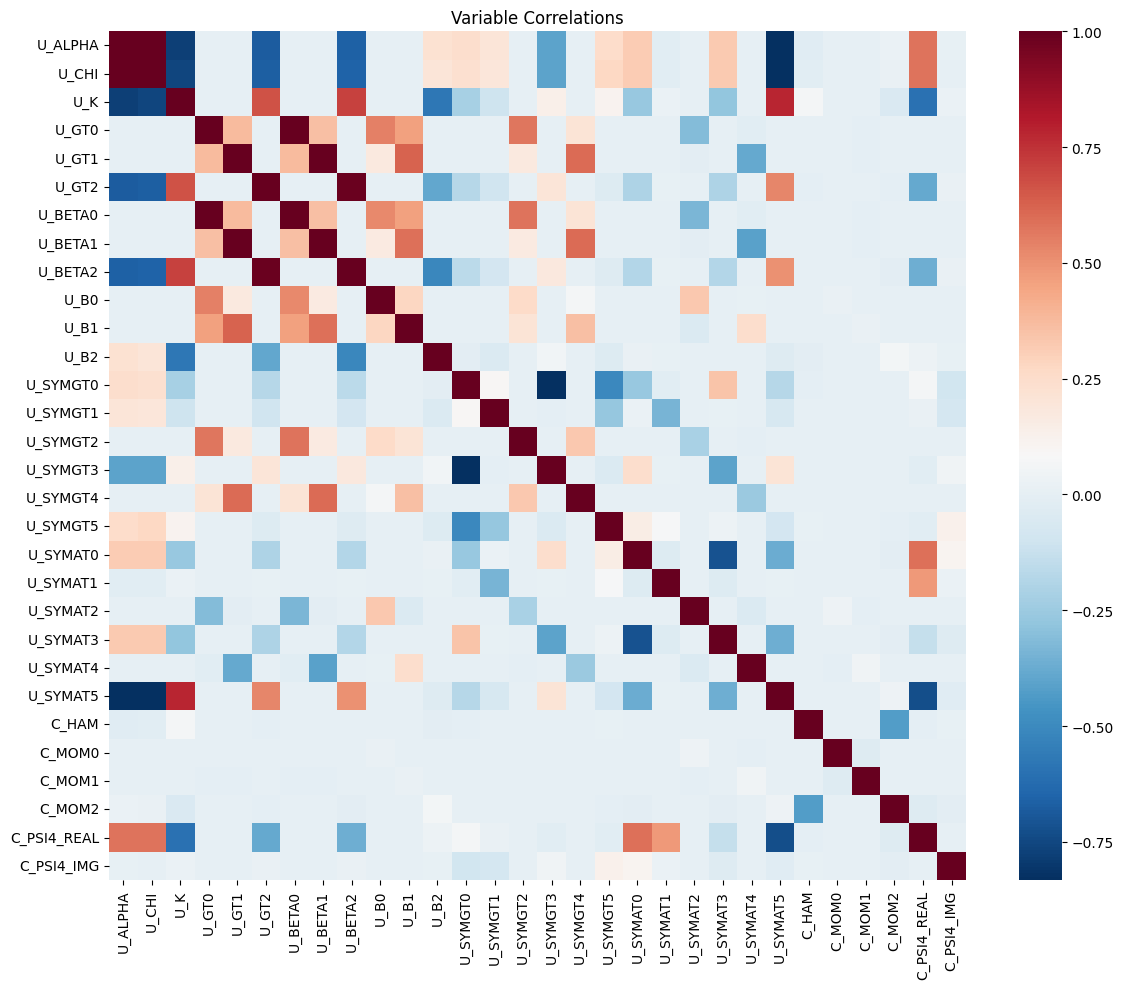

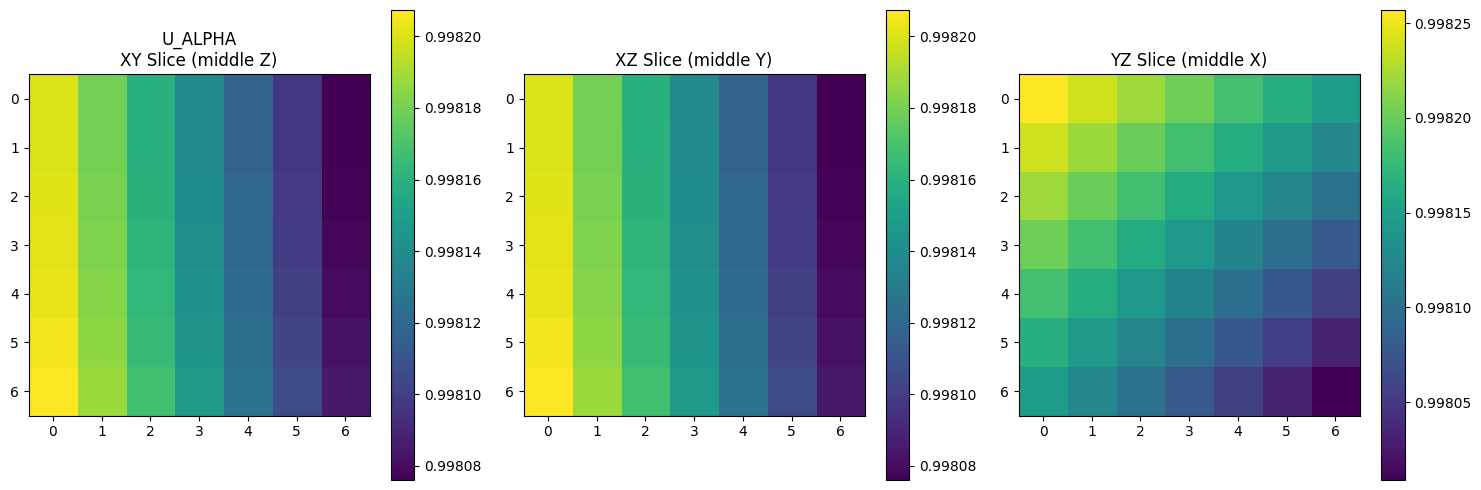

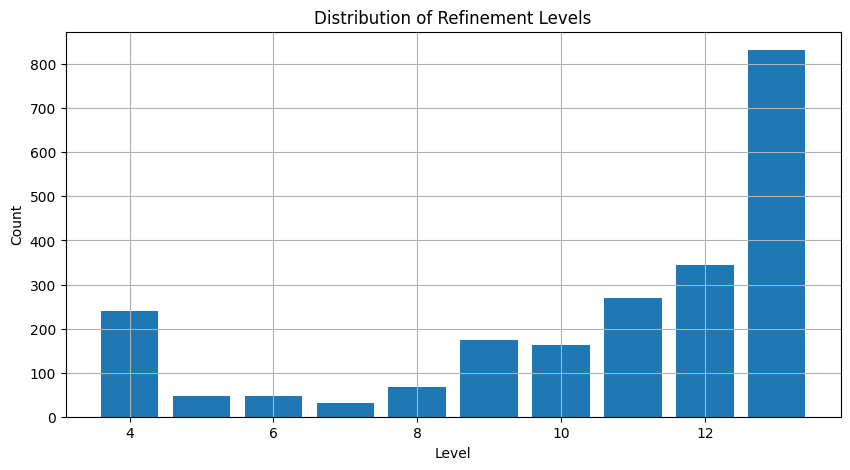


Core data statistics:
Shape of core data: (30, 2218, 5, 5, 5)
Original shape: (30, 2218, 7, 7, 7)

Comparison of original vs core:
Original block size: (7, 7, 7) (7x7x7)
Core block size: (5, 5, 5) (5x5x5)


In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# First, let's examine the structure of your HDF5 file
def print_hdf5_structure(filename):
    with h5py.File(filename, "r") as f:
        print("HDF5 file structure:")
        def print_structure(name, obj):
            print(f"{'  ' * name.count('/')}{name}: {type(obj)}")
            if isinstance(obj, h5py.Dataset):
                print(f"{'  ' * (name.count('/')+1)}Shape: {obj.shape}")
                print(f"{'  ' * (name.count('/')+1)}Type: {obj.dtype}")
        f.visititems(print_structure)

# Print the structure
filename = "bssn_gr_14800_extracted.hdf5"
print_hdf5_structure(filename)

# Now let's read the actual data structure
def read_data(filename):
    with h5py.File(filename, "r") as f:
        var_names = f["vars"][:]
        var_data = f["var_data"][:]
        centers = f["centers"][:]
        levels = f["levels"][:]
        dx = f["dx"][:]
        dy = f["dy"][:]
        dz = f["dz"][:]
        
    return var_names, var_data, centers, levels, dx, dy, dz

# Load the data
var_names, var_data, centers, levels, dx, dy, dz = read_data(filename)

# Print basic information
print("\nData shapes:")
print(f"Variable data shape: {var_data.shape}")
print(f"Centers shape: {centers.shape}")
print(f"Levels shape: {levels.shape}")
print(f"\nNumber of variables: {len(var_names)}")
print("Variable names:")
for i, name in enumerate(var_names):
    if isinstance(name, bytes):
        name = name.decode('utf-8')
    print(f"{i}: {name}")

# Extract 5x5x5 cores from 7x7x7 blocks
def extract_core(var_data):
    """Extract 5x5x5 core from 7x7x7 blocks"""
    if len(var_data.shape) == 5:  # For the full dataset
        return var_data[:, :, 1:-1, 1:-1, 1:-1]
    elif len(var_data.shape) == 3:  # For a single block
        return var_data[1:-1, 1:-1, 1:-1]
    else:
        raise ValueError(f"Unexpected shape: {var_data.shape}")

# Basic statistics for each variable
var_stats = {
    'mean': np.mean(var_data.reshape(var_data.shape[0], -1), axis=1),
    'std': np.std(var_data.reshape(var_data.shape[0], -1), axis=1),
    'min': np.min(var_data.reshape(var_data.shape[0], -1), axis=1),
    'max': np.max(var_data.reshape(var_data.shape[0], -1), axis=1)
}

# Plot statistics for each variable
plt.figure(figsize=(15, 6))
for stat_name, stat_values in var_stats.items():
    plt.plot(stat_values, label=stat_name)
plt.title('Variable Statistics')
plt.xlabel('Variable Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

# Plot spatial distribution of blocks
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(centers[:, 0], 
                    centers[:, 1], 
                    centers[:, 2],
                    c=levels,
                    cmap='viridis')
plt.colorbar(scatter, label='Level')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.title('Spatial Distribution of Blocks')
plt.show()

# Plot correlation matrix between variables
corr_matrix = np.corrcoef([var_data[i].flatten() for i in range(len(var_names))])
plt.figure(figsize=(12, 10))
var_labels = [name.decode('utf-8') if isinstance(name, bytes) else name for name in var_names]
sns.heatmap(corr_matrix, 
            xticklabels=var_labels,
            yticklabels=var_labels,
            cmap='RdBu_r')
plt.title('Variable Correlations')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Visualize middle slices of the first variable for a single block
plt.figure(figsize=(15, 5))
first_block_idx = 0  # First block
first_var_idx = 0    # First variable

# Plot XY, XZ, and YZ middle slices
plt.subplot(131)
plt.imshow(var_data[first_var_idx, first_block_idx, :, :, 3], cmap='viridis')
plt.title(f'{var_labels[first_var_idx]}\nXY Slice (middle Z)')
plt.colorbar()

plt.subplot(132)
plt.imshow(var_data[first_var_idx, first_block_idx, :, 3, :], cmap='viridis')
plt.title('XZ Slice (middle Y)')
plt.colorbar()

plt.subplot(133)
plt.imshow(var_data[first_var_idx, first_block_idx, 3, :, :], cmap='viridis')
plt.title('YZ Slice (middle X)')
plt.colorbar()

plt.tight_layout()
plt.show()

# Distribution of refinement levels
plt.figure(figsize=(10, 5))
plt.hist(levels, bins=np.arange(levels.min(), levels.max()+2)-0.5,
         rwidth=0.8)
plt.title('Distribution of Refinement Levels')
plt.xlabel('Level')
plt.ylabel('Count')
plt.grid(True)
plt.show()

# Print some statistics about the 5x5x5 cores
core_data = extract_core(var_data)
print("\nCore data statistics:")
print(f"Shape of core data: {core_data.shape}")
print(f"Original shape: {var_data.shape}")
print("\nComparison of original vs core:")
print(f"Original block size: {var_data.shape[2:]} (7x7x7)")
print(f"Core block size: {core_data.shape[2:]} (5x5x5)")